# **CV Task 3**

## **DJS Synapse Learning Period**
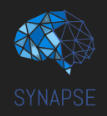

## importing and installing stuff

In [43]:
!pip install pydicom -q

In [44]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pydicom
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from ignite.engine import Events, create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss, RunningAverage
from ignite.contrib.handlers import ProgressBar
from sklearn.model_selection import train_test_split
from torchvision import models, transforms

## theoretical background

Until now, you have played around with Convolutional Neural Networks. For years, they were the dominant force in Computer Vision. Until a groundbreaking paper introduced transformers. Initially introduced for Natural Language Processing tasks, they were then also employed in Computer Vision as well. This is that original paper:

[Attention is All you Need](https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf)

If you didn't understand too much from that, worry not. Go through below resources as well:

[Basic overview (from an NLP viewpoint)](https://medium.com/inside-machine-learning/what-is-a-transformer-d07dd1fbec04)

[A bit more in depth (again, from an NLP viewpoint)](https://towardsdatascience.com/transformers-141e32e69591)


To get more background on how exactly vision transformers work:

[For visual learners](https://youtu.be/qU7wO02urYU?si=bj8Xj-DG2qDbwdnH)

[Read through this as well](https://www.v7labs.com/blog/vision-transformer-guide)

Transformers found their initial applications in natural language processing (NLP) tasks. To use this NLP model for computer vision tasks, we have to divide our input image into patches. After flattening the patches, we can treat each flattened patches as single word. We add positional embeddings to the linear projection of flattened patches. An extra token is added at the beginning for classification tasks. In BERT model, this token is called [CLS] token.

So if our input image size is (512, 512), after dividing the image into patches of size (16, 16), we get 1024 (32 times 32) patches. After flattening the patches and projecting the flattened patches, we have 1024 tokens. After adding positional embeddings and concatenating classification token at the beginning, we have 1025 tokens.

We then feed our tokens into the transformer encoder. Transformer encoder is made up of self attention and feedforward network. This [video](https://www.youtube.com/watch?v=_UVfwBqcnbM) by AssemblyAI explains the transformer architecture beautifully.

The number of tokens in the output of the transformer encoder is equal to number of input tokens. We take the first token from the output (corresponds to the classification token) and feed the token in a multilayer perceptron head for classification.

## dataset info
The dataset was contributed by mammography screening programs in Australia and the U.S. It includes detailed labels, with radiologists’ evaluations and follow-up pathology results for suspected malignancies.

The dataset is stored in dicom formats. Converting dicom data to png/jpg just by rescaling it will harm the quality of the data. [This notebook](https://www.kaggle.com/code/raddar/convert-dicom-to-np-array-the-correct-way/notebook) is an awesome resource for anyone working with dicom files for X-Ray.

To know more about how dicom images work, go through [this](https://towardsdatascience.com/understanding-dicom-bce665e62b72). They are specially used for X - Ray images.

## utility functions
We write some utility functions beforehand. To know how to work with PyDicom funtions, read [this](https://towardsdatascience.com/introducing-pydicom-its-classes-methods-and-attributes-518c1d71162).

In [45]:
def read_xray(file_path, img_size=None):
    """
    Read the dicom data and get the image
    Args:
        file_path: The path of the dicom file
        img_size: Size of the output image
    """

    # read file_path using pydicom
    dcm_data = pydicom.dcmread(file_path)
    
    # assign as pixel_array
    img = dcm_data.pixel_array
    

    # check if the photo is Monochrome
    if dcm_data.PhotometricInterpretation == "MONOCHROME1": 
        img = np.max(img) - img
        # we are inverting the pixel values. can you guess why?
        
    '''
    Answer here: 
    so the images in dicom format can be stored in two ways either 0 - black 0r 0 - white but our ml models expect only one type so we have to convert
    '''

    if img_size:
        # resize to img_size
        img = cv.resize(img,img_size)

    # Add channel dim at First
    img = np.expand_dims(img,axis=0)
    

    # Converting img to float32
    img = img.astype(np.float32)
    
    # normalize img
    img = img/(np.max(img))
    
    # convert to float32

    return img

In [46]:
#Try displaying 1 image


In [47]:
def patchify(batch, patch_size):
    """
    Patchify the batch of images

    Shape:
        batch: (b, h, w, c)
        output: (b, nh, nw, ph, pw, c)
    """
    
    # assign shape of batch
    '''b = batch size, c = channels, h,w = height and width'''
    b, c, h, w = batch.shape
    
    # which size should be assigned here?
    ph,pw = patch_size
    nh = h//ph
    nw = w//pw
    
    
    # calculate this
    batch_patches = batch.reshape(b, c, nh, ph, nw, pw)
    
    # Look into torch.reshape to get the patches
    batch_patches = batch_patches.permute(0, 2, 4, 3, 5, 1)
    
    # then, change the order of dimensions as required for the output using torch.permute

    return batch_patches

We test our `patchify` function on a single image.

Image shape: (1, 512, 512)
Batch shape: 1 1 512 512
Batch patches shape: 1 32 32 16 16 1
Patches shape: 32 32 16 16 1
nh, nw, ph, pw, c = (32, 32, 16, 16, 1)
nh, nw = (32, 32)


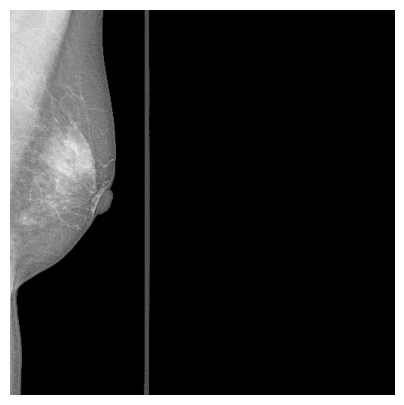

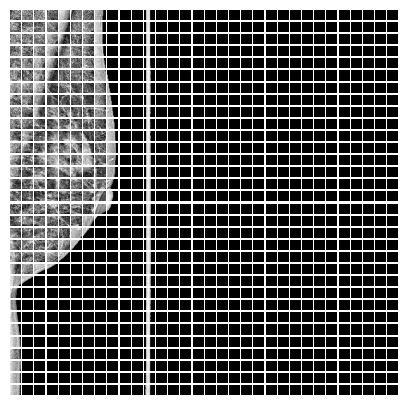

In [48]:
FILE_PATH = ('/kaggle/input/rsna-breast-cancer-detection/'
             'train_images/10006/1459541791.dcm')

img = read_xray(FILE_PATH, img_size=(512, 512))
print("Image shape:",img.shape) #c, h, w

batch = torch.tensor(img[None])
print("Batch shape:", *batch.shape)

patch_size = (16, 16)
batch_patches = patchify(batch, patch_size)
print("Batch patches shape:", *batch_patches.shape) #b, nh, nw, ph, pw, c

patches = batch_patches[0]
print("Patches shape:", *patches.shape) #nh, nw, ph, pw, c

nh, nw, ph, pw, c = patches.shape
print(f"nh, nw, ph, pw, c = {nh, nw, ph, pw, c}")

plt.figure(figsize=(5, 5))
plt.imshow(img[0], cmap="gray")
plt.axis("off")

print(f"nh, nw = {nh, nw}")
plt.figure(figsize=(5,5))

for i in range(nh):
    for j in range(nw):
        plt.subplot(nh, nw, i * nw + j + 1)
        #plt.imshow(patches[0, i, j], cmap="gray")
        plt.imshow(patches[i, j], cmap="gray")
        plt.axis("off")

In [49]:
def get_mlp(in_features, hidden_units, out_features):
    """
    Returns a MLP head
    """
    '''
    mlp = multi level perceptron ==> Neural network
    '''
    dims = [in_features] + hidden_units + [out_features]
    layers = []
    for dim1, dim2 in zip(dims[:-2], dims[1:-1]):
        # Add a Linear ReLU Layer to layers for each iteration
        layers.append(nn.Linear(dim1,dim2))
        layers.append(nn.relu())
        
    # Add a final Linear Layer and return its Sequential Model
    layers.append(nn.linear(dim[-2],dim[-1]))
    
    return nn.Sequential(*layers)

## image to sequence block
This Block takes a batch of image as input and returns a batch of sequences. Later on we feed this sequences into the transformer encoder.

In [50]:
class Img2Seq(nn.Module):
    """
    This layers takes a batch of images as input and
    returns a batch of sequences

    Shape:
        input: (b, h, w, c)
        output: (b, s, d)
    """
    def __init__(self, img_size, patch_size, n_channels, d_model):
        super().__init__()
        self.patch_size = patch_size
        self.img_size = img_size

        nh, nw = img_size[0] // patch_size[0], img_size[1] // patch_size[1]
        n_tokens = nh * nw

        token_dim = patch_size[0] * patch_size[1] * n_channels
        
        # Create a Linear layer with appropriate dimensions
        self.linear = nn.Linear(token_dim, d_model)
        '''
        Creates a weight matrix of (token_dim, d_model) and bias matrix of (d_model, 1), and multiplies like linear regression
        y = wX + b
        '''
        
        # we create 2 Learnable Parameters using torch.randn for initialization. 
        # one is the Embedding Parameter of a Special Transformer Token. 
        # the other is the Positional Embeddings.
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_emb = nn.Parameter(torch.randn(n_tokens, d_model))

    def __call__(self, batch):
        batch = patchify(batch, self.patch_size)

        b, c, nh, nw, ph, pw = batch.shape
        batch = batch.reshape(b, nh * nw, -1)
        emb = self.linear(batch)
        emb = emb + self.pos_emb
        Cls = self.cls_token.expand(b, -1, -1)

        # Flattening the patches using reshape and permute. Adjust Dimensions carefully.

        return torch.cat([Cls, emb], axis=1)

## visual transformer module
This modules wraps up everything. We can divide this module into 3 parts:
* An image to sequence encoder
* Transformer encoder
* Multilayer perceptron head classification

We use `torch.nn.TransformerEncoder` and `torch.nn.TransformerEncoderLayer` to implement our transformer encoder. We highly recommend to read the official documentation to [learn more about the layers](https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html).
For the loss function, we will be using [gelu](https://arxiv.org/abs/1606.08415). You can also use this video to [learn about it](https://www.youtube.com/watch?v=FWhMkpo9yuM).

In [51]:
class ViT(nn.Module):
    def __init__(
        self,
        img_size,
        patch_size,
        n_channels,
        d_model,
        nhead,
        dim_feedforward,
        blocks,
        mlp_head_units,
        n_classes,
    ):
        super().__init__()
        """
        Args:
            img_size: Size of the image
            patch_size: Size of the patch
            n_channels: Number of image channels
            d_model: The number of features in the transformer encoder
            nhead: The number of heads in the multiheadattention models
            dim_feedforward: The dimension of the feedforward network model in the encoder
            blocks: The number of sub-encoder-layers in the encoder
            mlp_head_units: The hidden units of mlp_head
            n_classes: The number of output classes
        """
        self.img2seq = Img2Seq(img_size, patch_size, n_channels, d_model)
        
        # create an encoder layer for the head of the model using Gelu activation. 
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            activation='gelu',
            batch_first=True
        )


        # make sure you set the parameter that gives output as (batch_size, sequence, feature)
        
        # create an encoder block
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=blocks)
        
        # create the output activation function based on the number of classes (sigmoid or softmax)
        self.output = nn.Sigmoid() if n_classes == 1 else nn.Softmax()

    def __call__(self, batch):

        batch = self.img2seq(batch)
        batch = self.transformer_encoder(batch)
        batch = batch[:, 0, :]
        batch = self.mlp(batch)
        output = self.output(batch)
        return output

## trainingHere, we design a simple training to loop to train or `ViT` model on a subset of dataset. We use an already cropped dataset.

In [52]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

## dataset loading
We will be using the [CLAHE](https://www.geeksforgeeks.org/clahe-histogram-eqalization-opencv/) algorithm to improve contrast between the tiled images. Apart from this, we are using the pytorch data handling modules like DataLoaded which you can read about [here](https://pytorch.org/docs/stable/data.html).

In [53]:
class RSNADataset(Dataset):

    def __init__(self, df, img_path):
        self.df = df
        self.img_path = img_path

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        patient_id, image_id, cancer = self.df.iloc[idx][['patient_id', 'image_id', 'cancer']]
        file = os.path.join(self.img_path, f'{patient_id}_{image_id}.png')
        
        # read file
        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        # use cv2.createCLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        
        # apply clahe to file
        img = clahe.apply(img)
        
        # normalize file
        img = img.astype('float32') / 255.0
        
        X = torch.tensor(file[np.newaxis].astype('float32')).to(device)
        y = torch.tensor([cancer]).float().to(device)
        return X, y

In [54]:
df = pd.read_csv('/kaggle/input/rsna-breast-cancer-detection/train.csv')
df.head()

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True


In [55]:
# apply value_counts on appropriate column
counts = df.cancer.value_counts()

df['weights'] = df['cancer'].apply(lambda x: 1/counts[x]) # why this?

train_df, val_df = train_test_split(df, test_size=0.25, stratify=df['cancer'])

In [56]:
df.head()

,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case,weights
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False,0.000019
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False,0.000019
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False,0.000019
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False,0.000019
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True,0.000019


In [57]:
img_path = '/kaggle/input/rsna-breast-cancer-512-pngs'
train_samples = len(train_df)#Set train samples
val_samples = len(val_df)#Set validation samples
BATCH_SIZE = 16#Try atleast 2 batch sizes and add the results below in a markdown cell

train_ds = RSNADataset(train_df, img_path)
val_ds = RSNADataset(val_df, img_path) # call as above

train_sampler = WeightedRandomSampler(train_df['weights'].values, train_samples)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler)

val_sampler = WeightedRandomSampler(val_df['weights'].values, val_samples) # sample as above
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, sampler=val_sampler) # load as above

## model creation and training start

In [58]:
model = ViT(
    img_size = (512, 512),
    patch_size = (16, 16),
    n_channels = 1,
    d_model = 1024,
    nhead = 4,
    dim_feedforward = 1024,
    blocks = 8,
    mlp_head_units = [512, 512],
    n_classes = 1,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)# run Adam optimizer on model
criterion = nn.BCELoss()# use BCE Loss (Explain why)

trainer = create_supervised_trainer(model, optimizer, criterion, device=device)
val_metrics = {
    "bce": Loss(criterion),
    "accuracy": Accuracy(output_transform=lambda out: (torch.round(out[0]), out[1]))
}

# create evaluator trainer
evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)

In [60]:
import cv2
import numpy as np
import torch
log_interval = 10
max_epochs = 10
best_loss = float('inf')

RunningAverage(output_transform=lambda x: x).attach(trainer, 'loss')

pbar = ProgressBar()
pbar.attach(trainer, ['loss'])

@trainer.on(Events.EPOCH_COMPLETED)
def log_validation_results(trainer):
    global best_loss
    evaluator.run(val_loader)
    loss = evaluator.state.metrics['bce']
    acc = evaluator.state.metrics['accuracy']
    if loss < best_loss:
        
        # in this line, save best loss in best_loss
        best_loss = loss
        print("New loss:", best_loss)
        
        # in this line, use torch.save() to save model as 'best_model_vit.pt'
    torch.save(model.state_dict(), 'best_model_vit.pt')
        
    print(f"Validation Results - Epoch: {trainer.state.epoch} Accuracy: {acc:.4f} Avg loss: {loss:.4f}")

output_state = trainer.run(train_loader, max_epochs=max_epochs)

<h1>Research Task:</h1>

(AB TAK KA TASK ITSELF WAS KINDA RESEARCH TASK LOL, but still)


Read any research paper which involves usage of Vision Transformer. Ensure it satisfies the following conditions
(Paper ko access karna from college ka website)

1. Recent paper, published within last 5 years
2. Not used for basic object detection and image segmentation

And you have to explain

1. Purpose of the papers
2. Novelty of the papers
3. Comparison with some other papers
4. Methodology

Also, what improvement you feel can be done in the paper - either pre-processing POV, dataset handling, methodology optimization, more visually simple diagrams etc (Ek simple addition which u feel can make that paper more better, don't worry just ek simple exercise to make u think aur kn)

# **End of Task**

> ©Synapse 2025 - 2026
